In [86]:
import numpy as np
import matplotlib.pyplot as plt

import copy
import math

def compute_cost_nfeatures(x, y, w, b):
    m = x.shape[0]
    loss_sum = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # single feature : w*x[i] + b #y^
        loss = (predict - y[i]) ** 2
        loss_sum += loss
    cost = loss_sum * (1/(2*m))
    return cost
def compute_gradient_nfeatures(x, y, w, b):
    # m = x.shape[0]
    # n = x.shape[1]
    m, n = x.shape
    dj_dw = np.zeros(n) # or np.zeros((n,))
    dj_db = 0
    for i in range(m):
        predict = np.dot(x[i], w) + b # predict using all feature in a row
        loss = predict - y[i] # loss for all features in a row
        # update dj_dw for each feature
        for j in range(n):
            dj_dw[j] += loss*x[i,j] # loss from all features * value form each single feature
        dj_db += loss
    
    dj_dw/=m
    dj_db/=m
    return dj_dw, dj_db
def gradient_descent(x, y, w, b, alpha, epochs, compute_cost_nfeatures, compute_gradient_nfeatures):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    m, n = x.shape
    cost_history = []
    params_history = []

    for i in range(epochs):
        #Calc Gradients
        dj_dw, dj_db = compute_gradient_nfeatures(x, y, w, b)
        #Update Parameters
        w -= alpha * dj_dw # Update each weight using its corresponding gradient, Element-wise update: w[j] = w[j] - alpha * dj_dw[j]
        b -= alpha * dj_db

        # Resource exacution
        if i < 10000:
            cost = compute_cost_nfeatures(x, y, w, b)
            cost_history.append(cost)
            params_history.append([w.copy(),b]) # as w is array, every iteration wil store same reference so use copy
        #Print Status
        if i% math.ceil(epochs/10) == 0:# after each 10 percent of epochs
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f} dj_dw : {dj_dw} w : {w}")

    return w, b, cost_history, params_history


<a name='PolynomialFeatures'></a>
## Polynomial Features

Above we were considering a scenario where the data was non-linear. Let's try using what we know so far to fit a non-linear curve. We'll start with a simple quadratic: $y = 1+x^2$

You're familiar with all the routines we're using. They are available in the lab_utils.py file for review. We'll use [`np.c_[..]`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html) which is a NumPy routine to concatenate along the column boundary.

[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]]
[  1   2   5  10  17  26  37  50  65  82 101 122 145 170 197 226 257 290
 325 362]
Iteration    0: Cost  1657.56 dj_dw : [-1814.5] w : [18.145]
Iteration  100: Cost   694.55 dj_dw : [-0.90155393] w : [15.64052925]
Iteration  200: Cost   588.48 dj_dw : [-0.68960393] w : [16.43032097]
Iteration  300: Cost   526.41 dj_dw : [-0.52748212] w : [17.03443732]
Iteration  400: Cost   490.10 dj_dw : [-0.40347419] w : [17.49652949]
Iteration  500: Cost   468.86 dj_dw : [-0.30861979] w : [17.84998652]
Iteration  600: Cost   456.43 dj_dw : [-0.2360651] w : [18.12034789]
Iteration  700: Cost   449.16 dj_dw : [-0.18056759] w : [18.3271489]
Iteration  800: Cost   444.90 dj_dw : [-0.13811722] w : [18.48533222]
Iteration  900: Cost   442.41 dj_dw : [-0.10564668] w : [18.60632757]


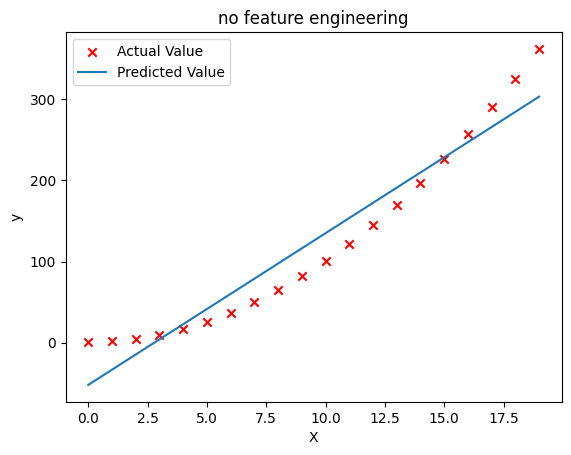

In [87]:
x = np.arange(0, 20, 1) # array from 0-19
y = 1 + x**2

X = x.reshape(-1, 1)
print(X)
print(y)

w_init = np.array([0.0])
b_init = 0
w_final, b_final , cost_history, param_history = gradient_descent(X, y, w_init, b_init, 1e-2, 1000, compute_cost_nfeatures, compute_gradient_nfeatures)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@w_final + b_final, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()

Well, as expected, not a great fit. What is needed is something like $y= w_0x_0^2 + b$, or a **polynomial feature**.
To accomplish this, you can modify the *input data* to *engineer* the needed features. If you swap the original data with a version that squares the $x$ value, then you can achieve $y= w_0x_0^2 + b$. Let's try it. Swap `X` for `X**2` below:

[[  0]
 [  1]
 [  4]
 [  9]
 [ 16]
 [ 25]
 [ 36]
 [ 49]
 [ 64]
 [ 81]
 [100]
 [121]
 [144]
 [169]
 [196]
 [225]
 [256]
 [289]
 [324]
 [361]]
[  1   2   5  10  17  26  37  50  65  82 101 122 145 170 197 226 257 290
 325 362]
Iteration    0: Cost  7329.22 dj_dw : [-28256.8] w : [0.282568]
Iteration  100: Cost     0.23 dj_dw : [0.00200013] w : [1.00436851]
Iteration  200: Cost     0.23 dj_dw : [0.00199921] w : [1.00436651]
Iteration  300: Cost     0.23 dj_dw : [0.0019983] w : [1.00436451]
Iteration  400: Cost     0.23 dj_dw : [0.00199738] w : [1.00436251]
Iteration  500: Cost     0.23 dj_dw : [0.00199647] w : [1.00436052]
Iteration  600: Cost     0.23 dj_dw : [0.00199555] w : [1.00435852]
Iteration  700: Cost     0.23 dj_dw : [0.00199464] w : [1.00435653]
Iteration  800: Cost     0.23 dj_dw : [0.00199373] w : [1.00435453]
Iteration  900: Cost     0.23 dj_dw : [0.00199281] w : [1.00435254]


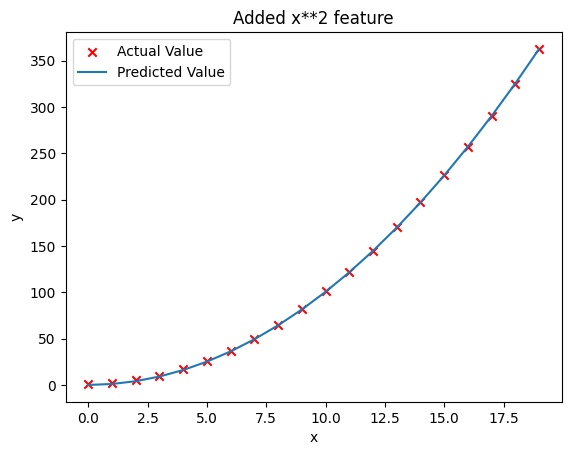

In [88]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2

# Engineer features 
X = x**2      #<-- added engineered feature, now X will be linear with Y
X = X.reshape(-1, 1)  #X should be a 2-D Matrix
print(X)
print(y)

w_init = np.array([0.0])
b_init = 0
w_final, b_final , cost_history, param_history = gradient_descent(X, y, w_init, b_init, 1e-5, 1000, compute_cost_nfeatures, compute_gradient_nfeatures)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,w_final) + b_final, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

Great! near perfect fit. Notice the values of $\mathbf{w}$ and b printed right above the graph: `w,b found by gradient descent: w: [1.], b: 0.0490`. Gradient descent modified our initial values of $\mathbf{w},b $ to be (1.0,0.049) or a model of $y=1*x_0^2+0.049$, very close to our target of $y=1*x_0^2+1$. If you ran it longer, it could be a better match. 

### Selecting Features
<a name='GDF'></a>
Above, we knew that an $x^2$ term was required. It may not always be obvious which features are required. One could add a variety of potential features to try and find the most useful. For example, what if we had instead tried : $y=w_0x_0 + w_1x_1^2 + w_2x_2^3+b$ ? 

Run the next cells. 

Iteration    0: Cost  1140.29 dj_dw : [  -1805.   -28133.3 -456665. ] w : [0.0001805  0.00281333 0.0456665 ]
Iteration 1000: Cost   328.54 dj_dw : [-109.92143364 -711.30797639   43.02643049] w : [0.01167144 0.07767216 0.0552169 ]
Iteration 2000: Cost   280.44 dj_dw : [-101.54254809 -657.18299918   39.75239972] w : [0.0222387  0.14605831 0.05108028]
Iteration 3000: Cost   239.39 dj_dw : [ -93.80125969 -607.17668684   36.72750782] w : [0.0320004  0.20924082 0.04725843]
Iteration 4000: Cost   204.34 dj_dw : [ -86.6490502  -560.97562766   33.93279646] w : [0.04101784 0.26761565 0.0437274 ]
Iteration 5000: Cost   174.43 dj_dw : [ -80.04109337 -518.29025915   31.35074995] w : [0.04934766 0.32154866 0.04046505]
Iteration 6000: Cost   148.90 dj_dw : [ -73.93597406 -478.85305318   28.96518544] w : [0.05704218 0.37137785 0.03745095]
Iteration 7000: Cost   127.10 dj_dw : [ -68.2954286  -442.41683934   26.76115156] w : [0.06414975 0.41741549 0.03466619]
Iteration 8000: Cost   108.49 dj_dw : [ -63.

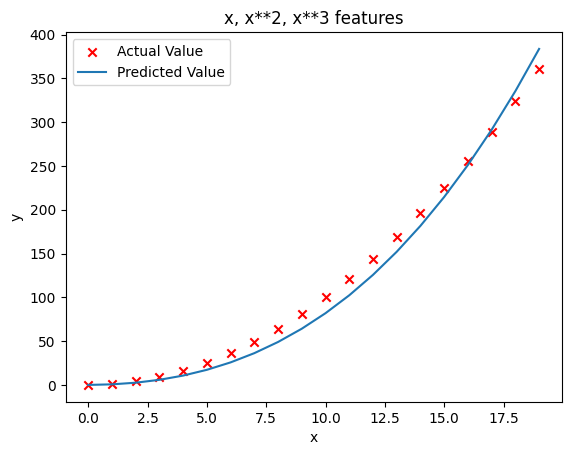

In [89]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature (Gradient will pick x **2 eventually by reducing weights for others)
# X =
# [ [0   0    0]
#  [1   1    1]
#  [2   4    8]
#  [3   9   27] ]
w_init = np.array([0.0 ,0.0 ,0.0])
b_init = 0
model_w, model_b , cost_history, param_history = gradient_descent(X, y, w_init, b_init, 1e-7, 10000, compute_cost_nfeatures, compute_gradient_nfeatures)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("x, x**2, x**3 features")
plt.plot(x, X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

### An Alternate View
Above, polynomial features were chosen based on how well they matched the target data. Another way to think about this is to note that we are still using linear regression once we have created new features. Given that, the best features will be linear relative to the target. This is best understood with an example. 

Note the value of $\mathbf{w}$, `[0.08 0.54 0.03]` and b is `0.0106`.This implies the model after fitting/training is:
$$ 0.08x + 0.54x^2 + 0.03x^3 + 0.0106 $$
Gradient descent has emphasized the data that is the best fit to the $x^2$ data by increasing the $w_1$ term relative to the others.  If you were to run for a very long time, it would continue to reduce the impact of the other terms. 
>Gradient descent is picking the 'correct' features for us by emphasizing its associated parameter that is x**2

Let's review this idea:
- Intially, the features were re-scaled so they are comparable to each other
- less weight value implies less important/correct feature, and in extreme, when the weight becomes zero or very close to zero, the associated feature useful in fitting the model to the data.
- above, after fitting, the weight associated with the $x^2$ feature is much larger than the weights for $x$ or $x^3$ as it is the most useful in fitting the data. 

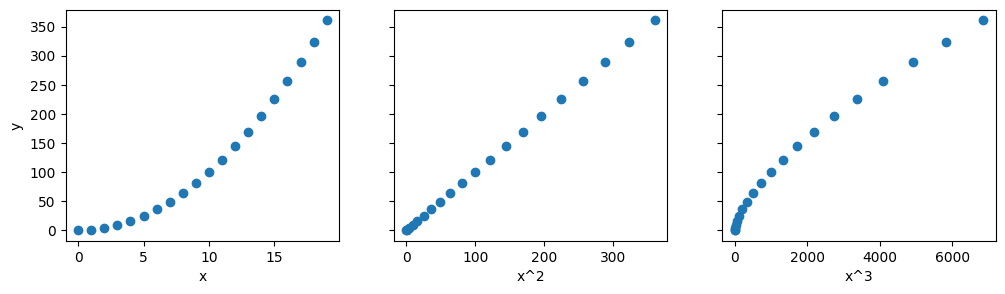

In [90]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature
X_features = ['x','x^2','x^3']

fig,ax=plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.show()


Above, it is clear that the $x^2$ feature mapped against the target value $y$ is linear. Linear regression can then easily generate a model using that feature.


### Scaling features
As described in the last lab, if the data set has features with significantly different scales, one should apply feature scaling to speed gradient descent. In the example above, there is $x$, $x^2$ and $x^3$ which will naturally have very different scales. Let's apply Z-score normalization to our example.

In [91]:
def zscore_normalize_features(x):
    # Computes  X, zcore normalized by column
    # X (ndarray (m,n))     : input data, m examples, n features
    # mean (ndarray (n,))     : mean of each feature
    # sigma (ndarray (n,))  : standard deviation of each feature

    mean = np.mean(x, axis = 0) # for each feature
    sigma = np.std(x, axis = 0) # for each feature
    x_norm = (x-mean)/sigma
    return x_norm, mean, sigma

# create target data
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X,axis=0)}")

# add mean_normalization 
X_norm, X_mu, X_sigma = zscore_normalize_features(X) 
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")



Peak to Peak range by column in Raw        X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.29501788 3.18076489 3.28307153]


Feature scaling allows this to converge much faster.   
Note again the values of $\mathbf{w}$. The $w_1$ term, which is the $x^2$ term is the most emphasized. Gradient descent has all but eliminated the $x^3$ term.

### Complex Functions
With feature engineering, even quite complex functions can be modeled:

Iteration    0: Cost     0.22 dj_dw : [0.16511324 0.16242158 0.19904021 0.23848724 0.27058268 0.29398768
 0.3099232  0.32006613 0.32591688 0.32866372 0.32920198 0.32819116
 0.32611185] w : [-0.01651132 -0.01624216 -0.01990402 -0.02384872 -0.02705827 -0.02939877
 -0.03099232 -0.03200661 -0.03259169 -0.03286637 -0.0329202  -0.03281912
 -0.03261119]
Iteration 100000: Cost     0.03 dj_dw : [-4.02297652e-05  2.54968214e-04 -3.68942486e-04 -1.14574441e-04
  1.78270313e-04  2.49105124e-04  1.44517735e-04 -2.31426635e-05
 -1.62123649e-04 -2.17509822e-04 -1.65067181e-04 -1.06137219e-06
  2.66336740e-04] w : [-3.70261573  3.54508947  6.45477618  0.34804967 -4.20534413 -4.99064235
 -3.20701798 -0.54386265  1.73401573  2.89704687  2.63082184  0.8899768
 -2.21720331]
Iteration 200000: Cost     0.03 dj_dw : [-4.28818452e-05  2.42527175e-04 -3.19533294e-04 -1.11618538e-04
  1.39410763e-04  2.05869809e-04  1.24749479e-04 -1.05887633e-05
 -1.24233150e-04 -1.71246165e-04 -1.32223554e-04 -4.60657787e-06


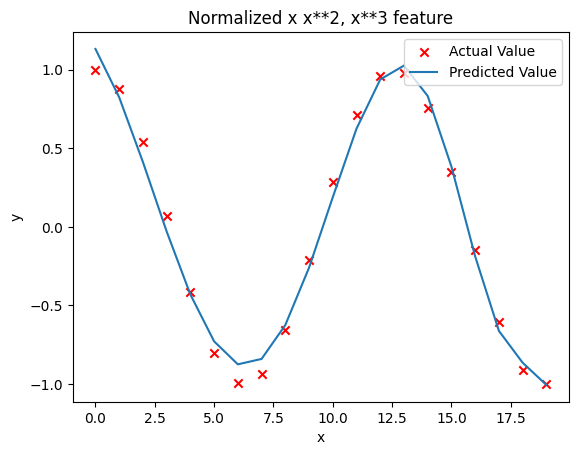

In [92]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X_norm, mean, sigma = zscore_normalize_features(X)

w_init = np.array([0.0,0,0,0,0,0,0,0,0,0,0,0,0])
b_init = 0
model_w, model_b , cost_history, param_history = gradient_descent(X_norm, y, w_init, b_init, 1e-1, 1000000, compute_cost_nfeatures, compute_gradient_nfeatures)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X_norm@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()


# AT END ONLY SOME REQUIRED FEATIRES WILL ONLY GET VALUES FOR WEIGHTS IN ORDER TO BEND MODEL TO FIT WITH OUTPIT COS WAVE. ... so if we have more featurees means model bending/flexibility



We have seen how:
- learned how linear regression can model complex, even highly non-linear functions using feature engineering
- recognized that it is important to apply feature scaling when doing feature engineering